# Model of the QUEST experiment interferometer

### The loss on the Power Recycling Mirror has been determined to keep the power at the beam splitter to be around 80 to 90 W

In [1]:
import numpy as np                         # Importing numpy
import matplotlib                          # For plotting
import matplotlib.pyplot as plt  
import finesse
import finesse.components as components
finesse.configure(plotting=True)
from scipy.signal import find_peaks
from finesse.analysis.actions import Xaxis, Maximize

In [2]:
kat = finesse.Model()
kat.parse(
    """    
    ###########################################################################
    ###   Input optics
    ###########################################################################
    #Laser with 300mW power and wavelength of 1064nm
    l L0 P=300m #W
    s s1 portA=L0.p1 portB=eo1.p1
    mod eo1 f=8M midx=0.2 order=2 mod_type=pm
    s s2 portA=eo1.p2 portB=prm.p1
    
    # Power recycling mirror
    m prm R=0.995 L=0.003 phi=0            #Loss=0.003
    s s3 portA=prm.p2 portB=bs.p1

    # Central beamsplitter
    bs bs T=0.5 R=0.5 alpha=45

    ###########################################################################
    ###   X arm
    ###########################################################################
    s lx bs.p3 emX.p1 L=1.835 #m
    m emX T=12.7u L=0.0 phi=90-0.55        #dark fringe offset of 0.55 degrees

    ###########################################################################
    ###   Y arm
    ###########################################################################
    s ly bs.p2 emY.p1 L=1.83-0.005 #m
    m emY T=0.0000127 L=0.0 phi=0.55       #dark fringe offset

    ###########################################################################
    ###   Output
    ###########################################################################
    pd beamsp bs.p1.i
    pd s_port bs.p1.o
    pd as_port bs.p4.o            # Photodetector at the asymmetric port


    fsig(1)
    sgen darmx lx.h
    sgen darmy ly.h phase=180
    """)

## Shot Noise Limited Sensitivity Plot simulated

C:\Users\joesa\miniconda3\envs\finesse\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\joesa\miniconda3\envs\finesse\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


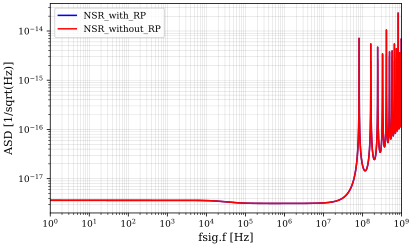

array([3.63709537e-18+0.j, 3.63709537e-18+0.j, 3.63709537e-18+0.j, ...,
       2.34468775e-16+0.j, 2.16432832e-16+0.j, 2.01549511e-16+0.j])

In [19]:
def get_QNLS(kat):
    _kat = kat.deepcopy()
    _kat.parse(f"""
    
        # Output the full quantum noise limited sensitivity
        qnoised NSR_with_RP bs.p4.o nsr=True
        #pd1 signal bs.p4.o f=fsig
        
        # Output just the shot noise limited sensitivity, considering only vacuum noise contributions
        qshot NSR_without_RP bs.p4.o nsr=True
        
        """)
    
    #_kat.modes("even", 4)
    _kat.modes("off")

    #return _kat.run("xaxis(L0.phase, lin, -90, 90, 360)")
    return _kat.run("xaxis(darmx.f, log, 1e0, 1e9, 16000)")

out = get_QNLS(kat)
out.plot("NSR_with_RP","NSR_without_RP", log=True, separate=False); #,"NSR_without_RP" xlabel='Frequency[Hz]', ylabel='Displacement[m/rtHz]'
out['NSR_with_RP']


In [4]:
ifo1 = kat.deepcopy()
# We use the 'Maximize' FINESSE action to find the value of m2.phi (the tuning of 
# mirror m2) for which the circulating power in the interferometer is maximum.
# In other words, we are asking: at what mirror phase does the detector store the 
# most optical power? 
sol = ifo1.run(Maximize(ifo1.beamsp, # "circulating power" detector
        parameter=ifo1.emY.phi,        # parameter to optimize 
        method="Nelder-Mead",
        fatol=1e-4,
        adaptive=True,
    )
)
print(f"Power : {-sol.result.fun:.6g} W at emY.phi={sol.result.x[0]:.6f} deg")

Power : 81.1028 W at emY.phi=0.547073 deg


Sensitivity : [3.14127288e-18+0.j 3.14127311e-18+0.j 3.14127336e-18+0.j ...
 2.11162067e-16+0.j 2.06209638e-16+0.j 2.01549511e-16+0.j]


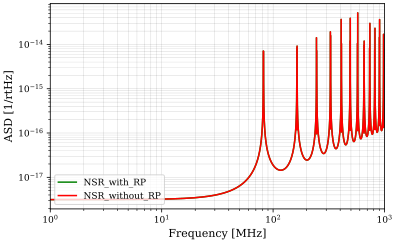

In [5]:
print("Sensitivity :",out['NSR_with_RP'])
fig1 = plt.figure()
plt.loglog(out.x1/1e6, out['NSR_with_RP'],label='NSR_with_RP', color='green')
plt.loglog(out.x1/1e6, out['NSR_without_RP'],label='NSR_without_RP',color='red')

plt.xlabel('Frequency [MHz]')
plt.ylabel('ASD [1/rtHz]')
plt.legend(loc=3)

## Power at the Asymmetric Port and Beam Splitter

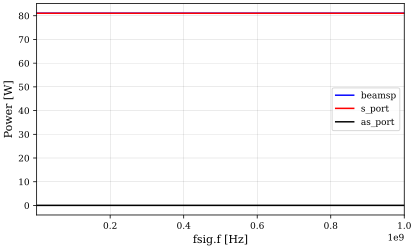

Power at beam splitter =  [81.07308899 81.07308899 81.07308899 ... 81.07308899 81.07308899
 81.07308899]
Power at asymmteric port =  [0.02987844 0.02987844 0.02987844 ... 0.02987844 0.02987844 0.02987844]


In [6]:
def power_vs_delL(kat):
    _kat = kat.deepcopy()
    _kat.parse(f"""
        """)

    _kat.modes("off")

    return _kat.run("xaxis(fsig, log, 10, 1E9, 10000)")

out1 = power_vs_delL(kat)
out1.plot(log=False, separate=False);
print('Power at beam splitter = ', out1['beamsp'])
print('Power at asymmteric port = ', out1['as_port'])

## Resonance of the optical cavities to the power of the laser by altering the tuning of the end mirror in the x-axis in the range $\phi_{emX} \in [-180,180]$

- Scan over the detuning DOF of end mirror in the x-axis from -180 deg to +180 deg with 400 points

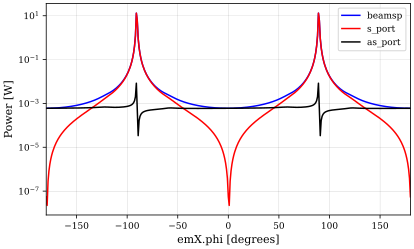

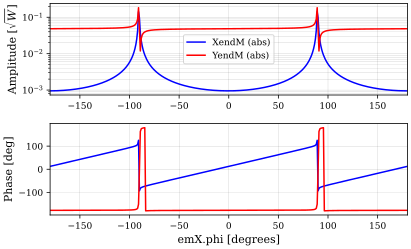

In [7]:
def showmotion(kat):
    _kat=kat.deepcopy()
    _kat.parse(f"""
        xd XendM emX.p1.o
        xd YendM emY.p1.o

              """)
    _kat.modes("off")
    return _kat.run("xaxis(emX.phi, lin, -180, 180, 400)")
    
out3 = showmotion(kat)
out3.plot(logy=True);

### Calculating the Shot noise sensitivity using the equation for the sensitivity at dark fringe

* $S^{sn}(f) = \sqrt{\dfrac{c \hbar \lambda}{4 \pi P_{bs}}}$

* FSR, FWHM, and Finesse are calculated between the beam splitter and the end mirror

In [8]:
import math
c=2.9979*1e8 #m/s
h=6.62606896*1e-34
h_bar=h/(2*math.pi)
wavelen=1064*1e-9  #Hz
P_bs=83  #W
L=1.8 #m
r1=math.sqrt(0.5)
r2=math.sqrt(0.9999873)
FSR= c/(2*L) #Calculating the Free Spectral Range using the equation FSR=c/2L

#Calculating the Full width half maximum using FWHM=(2FSR/π)sin^-1((1-(r1r2))/(2√(r1r2)))
FWHM=(2*FSR/math.pi)*math.asin((1-(r1*r2))/(2*math.sqrt(r1*r2)))
 
fin=FSR/FWHM #Calculating Finesse using finesse=FSR/FWHM

#Shot noise dependent sensitivity
sns=math.sqrt((c*h_bar*wavelen)/(4*math.pi*P_bs))


print("Shot noise limited sensitivity = ",sns,"m/rtHz")
print("Calculated FSR = ",FSR,"Hz")
print("Calculated FWHM = ", FWHM, "Hz")
print("Finesse = ",fin)

Shot noise limited sensitivity =  5.679020656811542e-18 m/rtHz
Calculated FSR =  83275000.0 Hz
Calculated FWHM =  9280254.795692991 Hz
Finesse =  8.973352761677223


### Transfer function, Signal and Quantum noise plotted separately

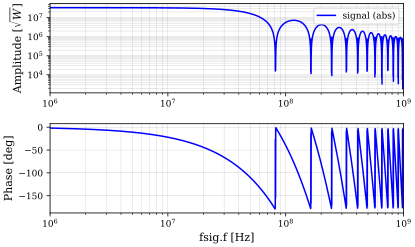

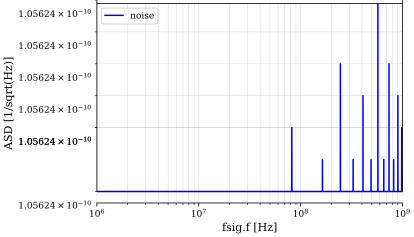

In [9]:
def ACsig(kat):
    _kat=kat.deepcopy()
    _kat.parse(f"""
        qnoised noise bs.p4.o #nsr=True
        pd1 signal bs.p4.o f=fsig    # a power detector looking at the fsig frequency fluctuations

              """)
    _kat.modes("off")
    return _kat.run("xaxis(fsig, log, 1e6, 1e9, 10000)") #select range 1e8 to 2e8 to zoom in
    
out4 = ACsig(kat)
#sol = kat.run("noxaxis()")
#out4['as_port'], out4['AC_fluct']
out4.plot('signal', 'noise', log=True, separate=True);

### Estimating the loss at the Power recycling mirror by sweeping across a range of loss values

- Power at the beam splitter is expected to be around 80 or 90 W

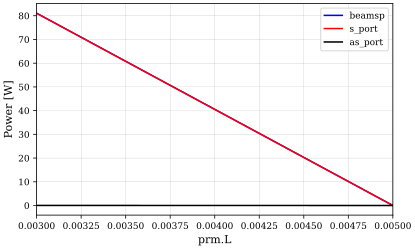

array([81.07308899, 80.9920159 , 80.91094281, ...,  0.16214618,
        0.08107309,  0.        ])

In [10]:
def lossPRM(kat):
    _kat = kat.deepcopy()
    _kat.parse(f"""
        """)

    _kat.modes("off")

    return _kat.run("xaxis(prm.L, lin, 0.003, 0.005, 1000)")

out5 = lossPRM(kat)
out5.plot( log=False, separate=False);
out5['beamsp']

### Estimating the loss at the end mirror in the x-axis

- The sensitivity should be arounf 5.5 e-18 m/rtHZ but here the sensitivity is higher, maybe there are other loss contributions

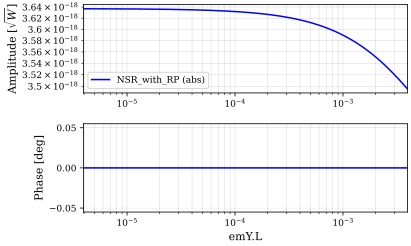

array([3.63709537e-18+0.j, 3.63688642e-18+0.j, 3.63667767e-18+0.j, ...,
       3.49548949e-18+0.j, 3.49539610e-18+0.j, 3.49530278e-18+0.j])

In [11]:
def lossEMX(kat):
    _kat = kat.deepcopy()
    _kat.parse(f"""
    qnoised NSR_with_RP bs.p4.o nsr=True
        """)

    _kat.modes("off")

    return _kat.run("xaxis(emY.L, lin, 0.0, 0.00395, 1000)")

out6 = lossEMX(kat)
out6.plot("NSR_with_RP", log=True, separate=True);
out6['NSR_with_RP']

### Determining the dark fringe offset ($\Delta\phi$ value) required to reach 30mW at the AS port

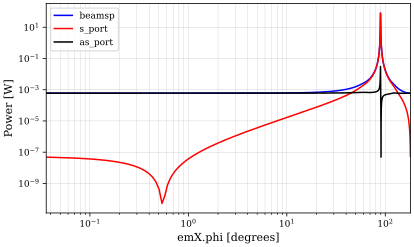

This is the output values in out7, contains power output at both BS and the AS port =  [(0.00059986, 5.53107650e-08, 0.0005998 )
 (0.00059987, 4.83121004e-08, 0.00059981)
 (0.00059987, 4.17868962e-08, 0.00059983) ...
 (0.00059985, 7.07284231e-08, 0.00059977)
 (0.00059985, 6.27828705e-08, 0.00059978)
 (0.00059986, 5.53107571e-08, 0.0005998 )]
Power at the AS port =  [0.0005998  0.00059981 0.00059983 ... 0.00059977 0.00059978 0.0005998 ]
Phase modulation =  [-180.    -179.964 -179.928 ...  179.928  179.964  180.   ]
Phi values at which the power at the AS port is or closer to 0.03 W = [-90.576 -90.54   89.424  89.46 ] and the corresponding power values :[0.03025304 0.02928739 0.03025304 0.02928739]


In [12]:
def adjustdf(kat):
    _kat = kat.deepcopy()
    _kat.parse(f"""
        """)

    _kat.modes("off")

    return _kat.run("xaxis(emX.phi, lin, -180, 180, 10000)")
out7 = adjustdf(kat)
out7.plot(log=True, separate=True)
as_port_P = np.array([d['as_port'] for d in out7.data])
phi = np.array(out7.x).flatten()
print('This is the output values in out7, contains power output at both BS and the AS port = ', out7.data)
print('Power at the AS port = ', as_port_P)
print('Phase modulation = ', phi)

target_P = 0.03 #W
isit = np.isclose(as_port_P, target_P, atol=1e-3)  #returns true if close or exact value found
idx = np.where(isit)[0]
phi_val = phi[idx]
print(f"Phi values at which the power at the AS port is or closer to {target_P} W = {phi_val} and the corresponding power values :{as_port_P[idx]}")

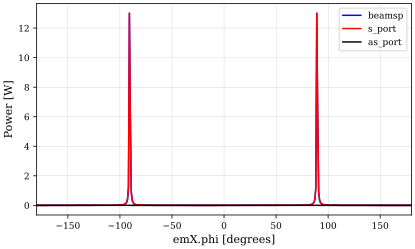

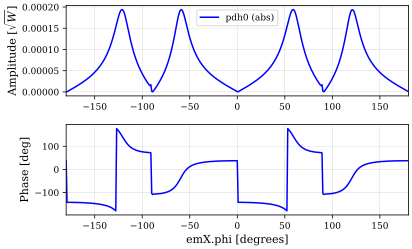

In [13]:
def sidebands(kat):
    _kat=kat.deepcopy()
    #for phase in np.linspace(0, 90, endpoint=True, num=6):
    _kat.parse(f"pd1 pdh0 node=bs.p4.o f=eo1.f")
    _kat.modes("off")
        
    return _kat.run("xaxis(emX.phi, lin, -180, 180, 400)")
    
out8 = sidebands(kat)
out8.plot(log=False, separate=True);


In [14]:
phi = np.array(out8.x).flatten()

pdh_traces = {
    name: np.array([d[name] for d in out8.data])
    for name in out8.outputs
    if name.startswith("pdh")  # only pick PDH detectors
}
#print(pdh_traces.items())

pdh_peaks = {}
for name, trace in pdh_traces.items():
    #print(name)
    #print(trace)
    peaks, _ = find_peaks(trace)
    pdh_peaks[name] = {
        "phi": phi[peaks],
        "height": trace[peaks]
    }
max_heights = {
    name: np.max(data["height"]) if len(data["height"]) > 0 else 0
    for name, data in pdh_peaks.items()
}
for name, h in max_heights.items():
    print(f"{name}: max peak height = {h:.6f}")

pdh0: max peak height = 0.000177-0.000057j


C:\Users\joesa\miniconda3\envs\finesse\lib\site-packages\scipy\signal\_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


C:\Users\joesa\miniconda3\envs\finesse\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\joesa\miniconda3\envs\finesse\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


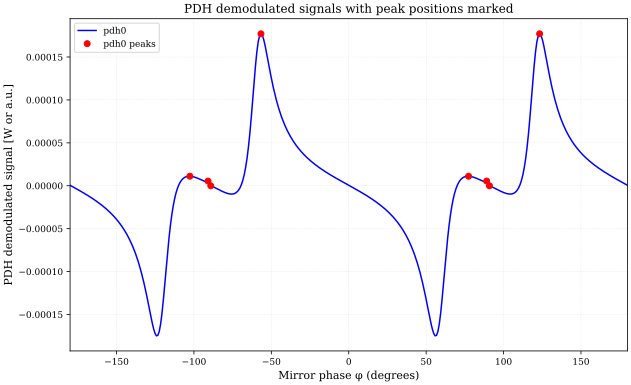

In [15]:
# --- Plot everything ---
plt.figure(figsize=(10,6))

# Plot all PDH traces
for name, trace in pdh_traces.items():
    plt.plot(phi, trace, label=name)

# Overlay peak markers
for name, data in pdh_peaks.items():
    plt.plot(data["phi"], data["height"], 'o', label=f"{name} peaks")

plt.xlabel("Mirror phase φ (degrees)")
plt.ylabel("PDH demodulated signal [W or a.u.]")
plt.title("PDH demodulated signals with peak positions marked")
plt.grid(True, which="both", ls=":")
plt.legend()
plt.show()


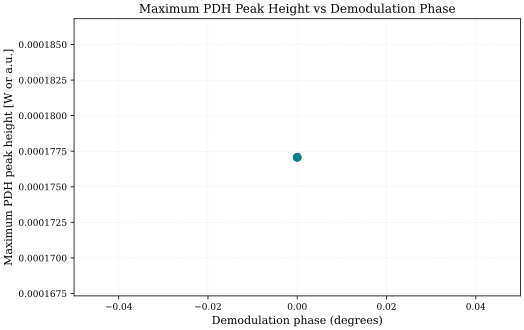

In [16]:
# --- Extract numeric phase values from PDH detector names ---
phases = [int(name.replace("pdh", "")) for name in max_heights.keys()]
heights = [max_heights[name] for name in max_heights.keys()]

# --- Plot max peak height vs demodulation phase ---
plt.figure(figsize=(8,5))
plt.plot(phases, heights, 'o-', color='teal', linewidth=2, markersize=8)
plt.xlabel("Demodulation phase (degrees)")
plt.ylabel("Maximum PDH peak height [W or a.u.]")
plt.title("Maximum PDH Peak Height vs Demodulation Phase")
plt.grid(True, which="both", ls=":")
plt.show()